# Sistema de Detección de Madurez de Bananas con YOLOv8

## Problema

En la industria agrícola es importante identificar el estado de madurez de las frutas para facilitar su clasificación y distribución.  
Este proyecto propone un sistema de **visión por computadora para detectar bananas y clasificar su estado de madurez**.

## Dataset y Etiquetado

Para crear el dataset se utilizaron **25 imágenes de bananas con diferentes estados de madurez**.

Las imágenes fueron **etiquetadas usando Roboflow**, donde se definieron dos clases:

- Banana madura  
- Banana no madura  

## Entrenamiento del Modelo

El modelo fue entrenado **localmente usando YOLOv8**.  
Después del etiquetado en Roboflow, el dataset fue exportado y utilizado para entrenar el modelo en un entorno local.

## Resultados

El sistema detecta bananas en imágenes o video y muestra:

- **Caja verde → Banana madura**
- **Caja roja → Banana no madura**

Esto permite identificar visualmente el estado de cada fruta.

## Conclusión

Este proyecto demuestra cómo **YOLOv8 puede aplicarse para automatizar la clasificación de frutas**, lo cual puede ser útil en procesos agrícolas o de control de calidad.

### **Step 1: Install Required Dependencies**

In [ ]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

### **Step 2: Import Required Libraries**

In [19]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

In [40]:
# Initialize RoboFlow (you'll need your API key)


from roboflow import Roboflow
rf = Roboflow(api_key="3shv8rIV1bWaKT7gCwIz")
project = rf.workspace("landers-workspace").project("banana-nh1kw")
version = project.version(4)

# CRÍTICO: Forzamos a que descargue la estructura exacta que YOLOv8 entiende
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to banana-4 in yolov8:: 100%|██████████| 116/116 [00:00<00:00, 1057.57it/s]


### **Step 6: Train Your Custom YOLO Model**

## Por motivos de pruebas

El modelo final está entrenado abajo, ya que tuve que realizar varias pruebas para conseguir un buen resultado.


### **Step 7: Evaluate Your Model**

In [6]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Cargar tu modelo entrenado
model = YOLO('./runs/detect/modelo_bananas_saturadas/weights/best.pt')

metrics = model.val(data='./banana-4/data.yaml')

print("Resultados del benchmark:")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.22  Python-3.13.7 torch-2.10.0+cpu CPU (AMD Ryzen 5 4600H with Radeon Graphics)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 223.4107.8 MB/s, size: 30.0 KB)
val: Scanning C:\Users\Lander\Desktop\U\10mo\Vision\deteccion\banana-4\valid\labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all          5          9      0.677      0.655      0.691      0.359
                maduro          4          6      0.355      0.667      0.469      0.252
             no maduro          3          3          1      0.643      0.913      0.466
Speed: 1.2ms preprocess, 76.9ms inference, 0.0ms loss, 9.9ms postprocess per image
Results saved to C:\Users\Lander\Desktop\U\10mo\Vision\deteccion\runs\detect\val4
Resultados del benchma

### **Step 8: Test Your Custom Model on an Image**


image 1/1 c:\Users\Lander\Desktop\U\10mo\Vision\deteccion\dataset\1.jpg: 480x640 1 maduro, 1 no maduro, 115.9ms
Speed: 6.3ms preprocess, 115.9ms inference, 10.3ms postprocess per image at shape (1, 3, 480, 640)


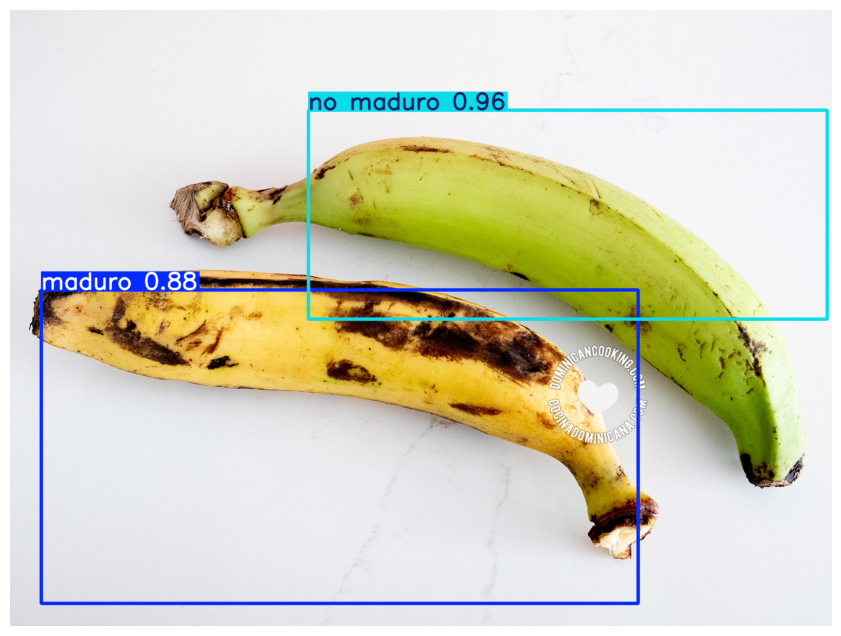

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Cargar tu modelo entrenado personalizado

custom_model = YOLO('./runs/detect/modelo_bananas_saturadas/weights/best.pt')

# 2. Probar en una imagen de muestra

ruta_imagen_prueba = './dataset/1.jpg'
results = custom_model(ruta_imagen_prueba, conf=0.25)

# 3. Mostrar los resultados en el Notebook
%matplotlib inline

for result in results:
    img = result.plot()  # Dibuja las cajas de detección (bounding boxes)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off') 
    plt.show()

In [74]:
from roboflow import Roboflow
from ultralytics import YOLO

# 1. Cargar el modelo base
model = YOLO('yolov8n.pt') 

# 2. Entrenar obligando a notar colores intensos
print("Iniciando entrenamiento con saturación exagerada...")
results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name='modelo_bananas_saturadas',
    
    # LA NUEVA MAGIA:
    hsv_h=0.0,   # 0.0: BLOQUEADO. El amarillo se queda amarillo y el verde, verde.
    hsv_s=1.0,   # 1.0: AL MÁXIMO. YOLO creará versiones con colores súper vibrantes y saturados.
    hsv_v=0.4,   # 0.4: Normal. Permite que YOLO oscurezca o aclare un poco la foto por si hay sombras.
    
    patience=35
)
print("¡Entrenamiento terminado!")

Iniciando entrenamiento con saturación exagerada...
Ultralytics 8.4.22  Python-3.13.7 torch-2.10.0+cpu CPU (AMD Ryzen 5 4600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Lander\Desktop\U\10mo\Vision\deteccion\banana-4/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=1.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modelo_bananas

### **Step 9: Test Your Custom Model on Video**

In [9]:
import cv2
from ultralytics import YOLO

# cargar modelo
model = YOLO('./runs/detect/modelo_bananas_saturadas/weights/best.pt')

cap = cv2.VideoCapture('./banana.mp4')

print("Procesando video... presiona 'q' para salir")

while cap.isOpened():

    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.35, iou=0.5)

    for r in results:
        for box in r.boxes:

            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # colores según clase
            if label == "maduro":
                color = (0,255,0)  # verde
                text = f"Maduro {conf:.2f}"

            elif label == "no_maduro":
                color = (0,0,255)  # rojo
                text = f"No Maduro {conf:.2f}"

            else:
                color = (255,255,0)
                text = f"{label} {conf:.2f}"

            cv2.rectangle(frame,(x1,y1),(x2,y2),color,2)
            cv2.putText(frame,text,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,color,2)

    cv2.imshow("Banana Ripeness Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Procesando video... presiona 'q' para salir

0: 384x640 5 no maduros, 59.3ms
Speed: 2.1ms preprocess, 59.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 no maduros, 52.7ms
Speed: 2.3ms preprocess, 52.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no maduros, 54.1ms
Speed: 2.1ms preprocess, 54.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no maduros, 50.4ms
Speed: 2.5ms preprocess, 50.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 no maduros, 50.9ms
Speed: 1.8ms preprocess, 50.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 no maduros, 46.7ms
Speed: 2.5ms preprocess, 46.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no maduros, 49.4ms
Speed: 1.7ms preprocess, 49.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 no maduros, 48.3ms
Speed: 1.6ms 

## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 20 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 3 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 3 | Properly trains a YOLOv8 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 2 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 2 | Implements real-time detection with custom classes and displays results correctly. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>